# Homework Exercise

Start from this notebook.

Assume house price depends not only on size, but also on number of windows.

n_windows = np.random.randint(3,8,n_samples)

house_prices = 100 + 0.2 * house_sizes - 0.00003 * house_sizes**2 + np.random.normal(0, 50, n_samples) + 15*n_windows

Try:
1) change the initial data, but keep using only house_sizes as regressor. What has changed?
3) adapt the notebook to using both house_sizes and n_windows as regressors. What has changed?
4) come up with a good way to visualize linear regression outputs with 2 regressors (Visualizzazione di 3 dimensioni)


## Step 1: Import the necessary libraries

In [16]:
# Import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from mpl_toolkits.mplot3d import Axes3D


from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

## Step 2: Create or load a dataset

In [17]:
np.random.seed(42)  # For reproducible results
n_samples = 200


# House sizes between 1000 and 3000 square feet
house_sizes = np.random.randint(1000, 3000, n_samples)
# generate number of widows per house
n_windows = np.random.randint(3,8,n_samples)



# House prices with some relationship to size plus random noise
house_prices = 100 + 0.2 * house_sizes - 0.00003 * house_sizes**2 + np.random.normal(0, 50, n_samples) + 15*n_windows


# Create a DataFrame
data = pd.DataFrame({
    'Size': house_sizes,
    'Num Windows': n_windows,
    'Price': house_prices
})

# Display the first 5 rows of the dataset
data.head()

,Size,Num Windows,Price
0,2126,6,500.535693
1,2459,7,478.990608
2,1860,6,368.117602
3,2294,7,529.312774
4,2130,7,417.321303


In [18]:
data["Num Windows"].unique()

array([6, 7, 5, 4, 3])

## Step 3: Visualize the data
Visualizzo i dati, mantendo lo scatter usato nel notebook precedente, dove aggiungo la terza componente, che sarà il numero delle finestre (la grandezza e il colore dei pallini indicherà più o meno finistre)

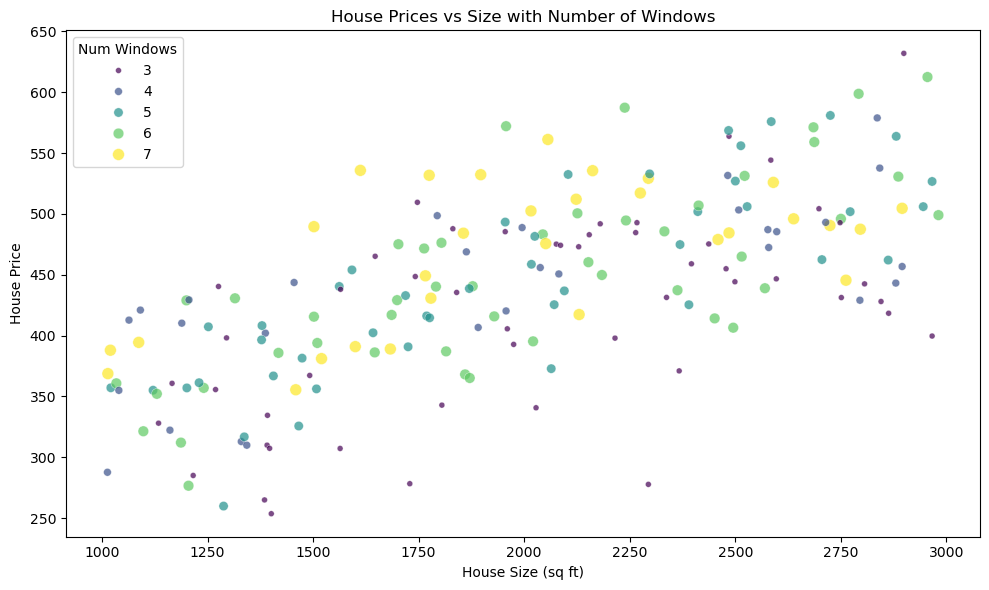

In [19]:
# Seaborn scatter plot
plt.figure(figsize=(10, 6))
sns.scatterplot(data=data, x='Size', y='Price', 
                hue='Num Windows', size='Num Windows', 
                palette='viridis', alpha=0.7)
plt.title('House Prices vs Size with Number of Windows')
plt.xlabel('House Size (sq ft)')
plt.ylabel('House Price')
plt.tight_layout()
plt.show()

Plotto con 3D scatter plot

é bello **vedere** anche la terza dimensione come si "sparpaglia"

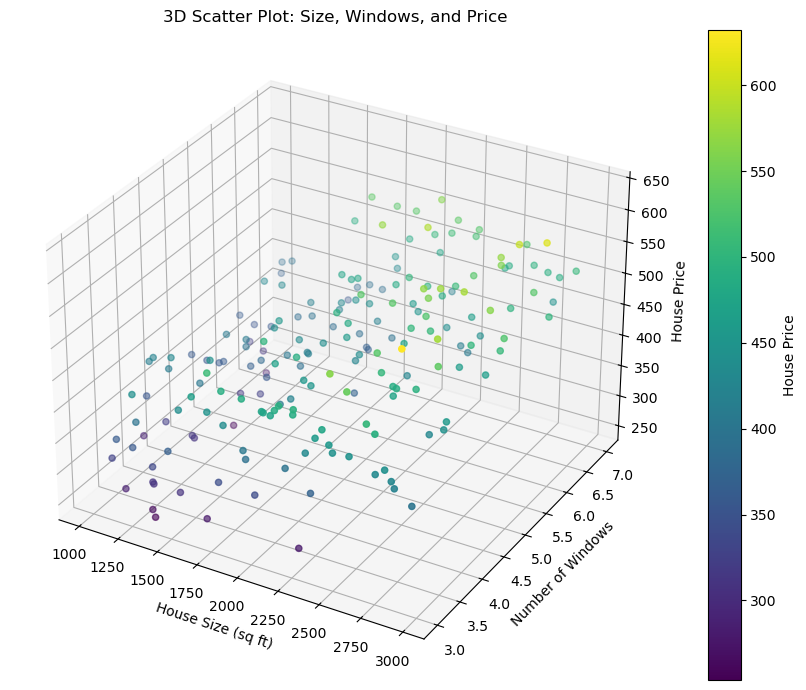

In [138]:
#3D scatter plot (requires Matplotlib's 3D plotting)
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')
scatter = ax.scatter(data['Size'], data['Num Windows'], data['Price'], 
                     c=data['Price'], cmap='viridis')
ax.set_xlabel('House Size (sq ft)')
ax.set_ylabel('Number of Windows')
ax.set_zlabel('House Price')
plt.colorbar(scatter, label='House Price')
plt.title('3D Scatter Plot: Size, Windows, and Price')
plt.tight_layout()
plt.show()

## Step 4-5-6: Split the data into training and testing sets| Create and train the model | Make prediction and evaluation

Creo una funzione da poter richiamare, passando come parametri i dati:
* X e y (quindi se singolo o multiplo)
* modello

In [20]:
def perform_regression_with_pipeline(X, y, regressor_names):
    """
    Perform linear regression 

    Parameters:
    -----------
    X : array-like
        Input features
    y : array-like
        Target variable
    regressor_names : str
        Description of regressors used

    Returns:
    --------
    tuple: (X_test, y_test, y_pred, pipeline)
    """
    # Suddividi i dati in training e test
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    # Crea una pipeline con solo la regressione lineare
    pipeline = make_pipeline(
        LinearRegression()  # Modello di regressione lineare senza normalizzazione
    )

    # Allena la pipeline
    pipeline.fit(X_train, y_train)

    # Previsioni
    y_pred = pipeline.predict(X_test)

    # Calcola le metriche di valutazione
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)

    # Mostra i risultati
    print(f"Regression Analysis: {regressor_names}")
    print("-" * 50)

    # Ottieni il modello dalla pipeline
    model = pipeline.named_steps['linearregression']

    # Equazione di regressione
    if X.shape[1] == 1:
        # Regressione con una sola feature
        print(f"Equation: y = {model.intercept_:.4f} + {model.coef_[0]:.4f} * x")
    else:
        # Regressione con più feature
        equation = f"Equation: y = {model.intercept_:.4f}"
        for i, coef in enumerate(model.coef_):
            feature_name = f"x{i+1}"
            equation += f" + {coef:.4f} * {feature_name}"
        print(equation)

    # Metriche di performance
    print("\nPerformance Metrics:")
    print(f"Mean Squared Error (MSE): {mse:.4f}")
    print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
    print(f"Mean Absolute Error (MAE): {mae:.4f}")
    print(f"R² Score: {r2:.4f}")

    # Parametri del modello
    print("\nModel Parameters:")
    print("Intercept:", model.intercept_)
    print("Coefficients:", model.coef_)

    # Analisi della varianza
    total_variance = np.var(y_test)
    explained_variance = total_variance * r2
    unexplained_variance = total_variance * (1 - r2)

    print("\nVariance Analysis:")
    print(f"Total Variance: {total_variance:.4f}")
    print(f"Explained Variance: {explained_variance:.4f}")
    print(f"Unexplained Variance: {unexplained_variance:.4f}")

    return X_test, y_test, y_pred, pipeline

In [21]:
# 1. Regression with only house sizes
X_single = data[['Size']]
y = data['Price']
X_test_single, y_test_single, y_pred_single, model_single = perform_regression_with_pipeline(X_single, y, "House Size")

Regression Analysis: House Size
--------------------------------------------------
Equation: y = 250.9276 + 0.0959 * x

Performance Metrics:
Mean Squared Error (MSE): 2570.3419
Root Mean Squared Error (RMSE): 50.6985
Mean Absolute Error (MAE): 41.3568
R² Score: 0.4739

Model Parameters:
Intercept: 250.92756221994784
Coefficients: [0.09589016]

Variance Analysis:
Total Variance: 4886.0357
Explained Variance: 2315.6938
Unexplained Variance: 2570.3419


### Risposta primo questito (change the initial data, but keep using only `house_sizes` as regressor. What has changed?)
I valori nell'altro notebok sono, dove il data-set **non conteneva** `Num Windows`:

* **Model coefficient (slope)**: 0.0931
* **Model intercept**: 185.1476
* **y** = 185.1476 + 0.0931 * x
* **Mean Squared Error**: 2670.55
* **Root Mean Squared Error**: 51.68
* **R-squared Score**: 0.4141

#### Risposta
Quindi anche se usiamo solo la dimensione della casa, cmq c'è stata una variazione in:
$y = a + b*x$
* `a` l'intercetta è aumentata, quindi è aumentata la pendenza.
* `b` il fattore di scala è aumentato di pochissimo

Questo perchè prima il prezzo base (l'intercetta) era determinata dalla sola relazione di `house_size` e `price`, introducendo una nuova variabile aumentiamo il valore dell'intercetta, in quanto sappiamo che il numero di finestre ha un impatto sul prezzo. Quindi non sarò più:

$Y = a + b * x$ ma sarà $Y = a + b * x + c$

Quindi il prezzo "base" è aumentato da  Model intercept: 185.1476 a Intercept: 444.77670591878086 e gli errori sembrano leggermente diminuiti.

In [22]:
# 2. Regression with house sizes and number of windows
X_multi = data.drop('Price', axis=1)
X_test_multi, y_test_multi, y_pred_multi, model_multi = perform_regression_with_pipeline(X_multi, y, "House Size and Number of Windows")

Regression Analysis: House Size and Number of Windows
--------------------------------------------------
Equation: y = 192.4216 + 0.0949 * x1 + 12.4270 * x2

Performance Metrics:
Mean Squared Error (MSE): 2456.9686
Root Mean Squared Error (RMSE): 49.5678
Mean Absolute Error (MAE): 40.3152
R² Score: 0.4971

Model Parameters:
Intercept: 192.42157133650088
Coefficients: [ 0.09494034 12.42696645]

Variance Analysis:
Total Variance: 4886.0357
Explained Variance: 2429.0671
Unexplained Variance: 2456.9686


### Risposta secondo questito (using both house_sizes and n_windows as regressors. What has changed?)
I valori usando solo `house_size` ma con il data set aggiornato con la nuova colonna sono
**Intercept**: 250.92756221994784
Coefficients: [0.09589016]

I valori calcolando le due regressioni:
**Intercept**: 192.42157133650088
Coefficients: [ 0.09494034 12.42696645]


#### Risposta
Significa che aggiungendo al calcolo il numero delle finestre il prezzo base della casa diminuisce, per quanto riguarda le performace dei modelli:

**Solo `house_size` nella regressione**
* Performance Metrics:
    * **Mean Squared Error (MSE)**: 2570.3419
    * **Root Mean Squared Error (RMSE)**: 50.6985
    * **Mean Absolute Error (MAE)**: 41.3568
    * **R² Score**: 0.4739

**Entrambi i parametri (`house_size` e `num_window`) nella regressione**
* Performance Metrics:
    * **Mean Squared Error (MSE)**: 2456.9686
    * **Root Mean Squared Error (RMSE)**: 49.5678
    * **Mean Absolute Error (MAE)**: 40.3152
    * **R² Score**: 0.4971

**Aggiungere la feature delle finestre migliora leggermente il modello(il modello con i due parametre spiega il 49,71% della variazione del prezzo contro il 47,30%), il prezzo base della casa è diminuito in quanto il size non è più l'unico responsabile del prezzo.**.


### Forse se venissero generate con correlazione cambierebbe?
Mostro graficamente che essendo generate randomicamente non hanno correlazione, quindi una casa più grande non significa (in questo caso specifico) più finestre e quindi più valore

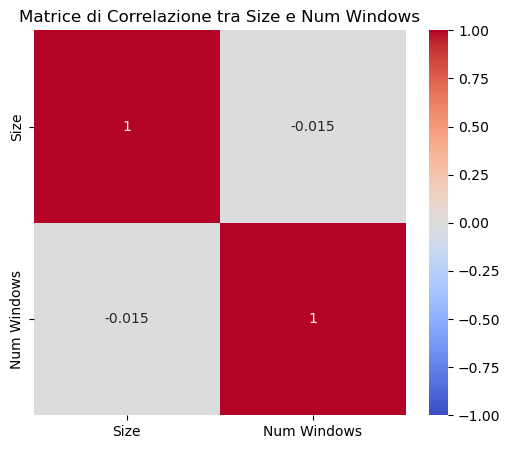

In [15]:
import seaborn as sns
import matplotlib.pyplot as plt

# Calcolare la matrice di correlazione
correlation_matrix = data[['Size', 'Num Windows']].corr()

# Visualizzare la matrice di correlazione con una heatmap
plt.figure(figsize=(6, 5))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Matrice di Correlazione tra Size e Num Windows')
plt.show()

## Risposta terzo quesito plottare i due regressori

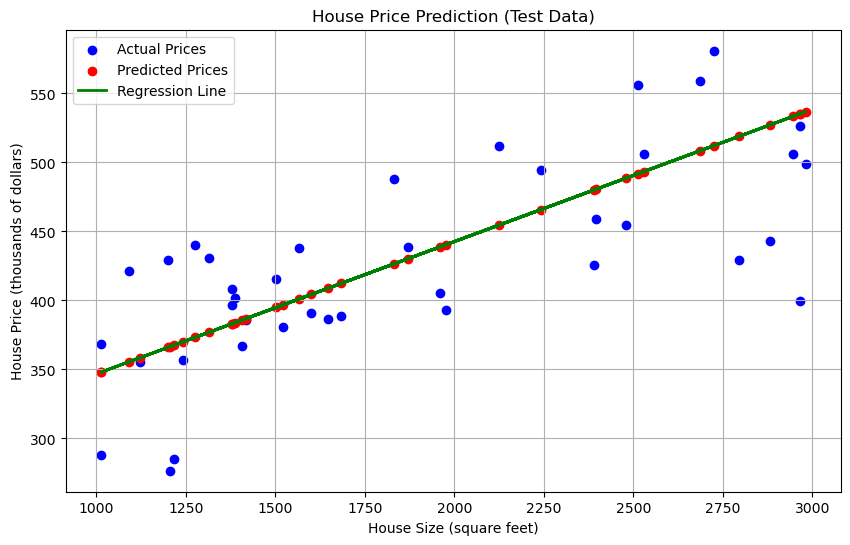

In [10]:
# Plot the original data points
plt.figure(figsize=(10, 6))
plt.scatter(X_test_single, y_test_single, color='blue', label='Actual Prices')

# Plot the predicted data points
plt.scatter(X_test_single, y_pred_single, color='red', label='Predicted Prices')

# Plot the regression line
plt.plot(X_test_single, y_pred_single, color='green', linewidth=2, label='Regression Line')

plt.title('House Price Prediction (Test Data)')
plt.xlabel('House Size (square feet)')
plt.ylabel('House Price (thousands of dollars)')
plt.legend()
plt.grid(True)
plt.show()

## Step 7: Visualize the results


### Risposta terzo questito
* Funzione per plottare a 3 dimensioni (visione delle predizioni rispetto ai dati veri)
* Funzione per plottare con 3 dimensioni e contour plot(vedere variazione di regressione nel piano)
* Funzione Heatmap 2D (andamento predizione senza una visualizzazione 3d)

In [11]:
def plot_3d_regression(X_test, y_test, y_pred, model):
    """
    Create a 3D visualization of linear regression with 2 regressors
    
    Parameters:
    -----------
    X_test : array-like
        Test features (should be 2D array)
    y_test : array-like
        Actual target values
    y_pred : array-like
        Predicted target values
    model : LinearRegression
        Trained linear regression model
    """
    # Ensure inputs are numpy arrays
    X_test = np.asarray(X_test)
    y_test = np.asarray(y_test)
    y_pred = np.asarray(y_pred)
    
    # Check and handle different input shapes
    if X_test.ndim == 1:
        X_test = X_test.reshape(-1, 1)
    
    # Ensure X_test is 2D and has 2 columns
    if X_test.shape[1] != 2:
        raise ValueError("X_test must have 2 columns (house size and number of windows)")
    
    # Create the 3D plot
    fig = plt.figure(figsize=(12, 8))
    ax = fig.add_subplot(111, projection='3d')
    
    # Scatter plot of actual data points
    scatter_actual = ax.scatter(X_test[:, 0], X_test[:, 1], y_test, 
                                c='blue', label='Actual Prices', alpha=0.7)
    
    # Scatter plot of predicted data points
    scatter_pred = ax.scatter(X_test[:, 0], X_test[:, 1], y_pred, 
                              c='red', label='Predicted Prices', alpha=0.7)
    
    # Create a meshgrid to plot the regression plane
    x1_min, x1_max = X_test[:, 0].min(), X_test[:, 0].max()
    x2_min, x2_max = X_test[:, 1].min(), X_test[:, 1].max()
    
    x1_surf = np.linspace(x1_min, x1_max, 100)
    x2_surf = np.linspace(x2_min, x2_max, 100)
    X1_surf, X2_surf = np.meshgrid(x1_surf, x2_surf)
    
    # Prepare grid for prediction
    grid_points = np.column_stack([X1_surf.ravel(), X2_surf.ravel()])
    
    # Predict prices for the meshgrid
    Z_surf = model.predict(grid_points).reshape(X1_surf.shape)
    
    # Plot the regression plane
    surf = ax.plot_surface(X1_surf, X2_surf, Z_surf, 
                           alpha=0.3, cmap="coolwarm", 
                           linewidth=0, antialiased=False)
    
    # Labels and title
    ax.set_xlabel('House Size (sq ft)')
    ax.set_ylabel('Number of Windows')
    ax.set_zlabel('House Price')
    ax.set_title('3D Linear Regression: House Size and Windows')
    
    # Add a legend (note: 3D plots don't support legend directly)
    # Instead, use text annotations
    ax.text2D(0.05, 0.95, "Blue: Actual Prices\nRed: Predicted Prices\nGreen: Regression Plane", 
              transform=ax.transAxes)
    
    plt.tight_layout()
    plt.show()

/opt/miniconda3/envs/ds_lecture_1/lib/python3.11/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


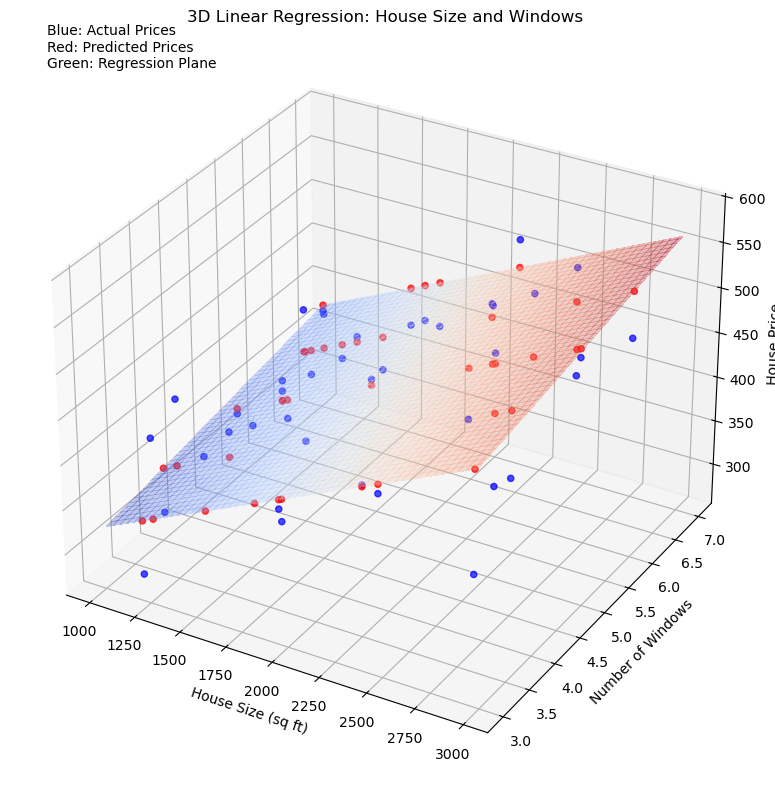

In [66]:
plot_3d_regression(X_test_multi, y_test_multi, y_pred_multi, model_multi)

In [12]:
def plot_3d_contour(X_test, y_test, y_pred, model):
    """
    3D Regression Plot with Contour Projection

    Parameters:
    X_test : array-like, shape (n_samples, 2)
        Feature matrix for testing (2D).
    y_test : array-like, shape (n_samples,)
        Actual target values.
    y_pred : array-like, shape (n_samples,)
        Predicted target values.
    model : trained regression model
        The trained model used for predictions.
    """
    X_test = np.asarray(X_test)
    y_test = np.asarray(y_test)
    y_pred = np.asarray(y_pred)
    
    fig = plt.figure(figsize=(12, 8))
    ax = fig.add_subplot(111, projection='3d')

    # Scatter actual vs predicted
    ax.scatter(X_test[:, 0], X_test[:, 1], y_test, c='blue', label='Actual')
    ax.scatter(X_test[:, 0], X_test[:, 1], y_pred, c='red', label='Predicted')

    # Create meshgrid for surface
    x1_min, x1_max = X_test[:, 0].min(), X_test[:, 0].max()
    x2_min, x2_max = X_test[:, 1].min(), X_test[:, 1].max()

    x1_surf = np.linspace(x1_min, x1_max, 100)
    x2_surf = np.linspace(x2_min, x2_max, 100)
    X1_surf, X2_surf = np.meshgrid(x1_surf, x2_surf)
    grid_points = np.column_stack([X1_surf.ravel(), X2_surf.ravel()])

    # Predict values on the grid
    Z_surf = model.predict(grid_points).reshape(X1_surf.shape)

    # Plot surface
    ax.plot_surface(X1_surf, X2_surf, Z_surf, cmap="coolwarm", alpha=0.4)

    # Contour lines on the bottom plane
    ax.contour(X1_surf, X2_surf, Z_surf, 20, cmap="coolwarm", offset=y_test.min())

    # Labels and title
    ax.set_xlabel('Feature 1')
    ax.set_ylabel('Feature 2')
    ax.set_zlabel('Target')
    ax.set_title('3D Regression with Contour Projection')

    plt.show()

/opt/miniconda3/envs/ds_lecture_1/lib/python3.11/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


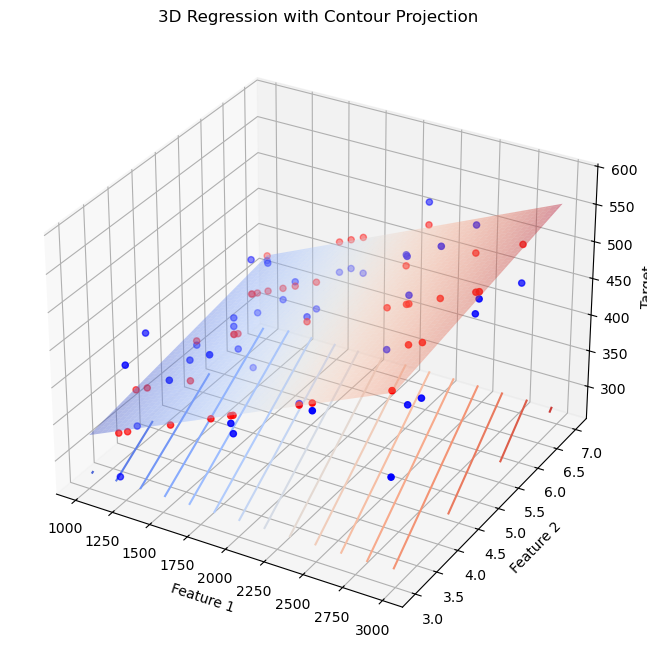

In [121]:
plot_3d_contour(X_test_multi, y_test_multi, y_pred_multi, model_multi)

In [69]:
def plot_2d_heatmap(X_test, y_pred, model):
    """
    2D Heatmap for Regression Predictions

    Parameters:
    X_test : array-like, shape (n_samples, 2)
        Feature matrix for testing (2D).
    y_pred : array-like, shape (n_samples,)
        Predicted target values.
    model : trained regression model
        The trained model used for predictions.
    """
    X_test = np.asarray(X_test)
    y_pred = np.asarray(y_pred)

    # Create meshgrid for heatmap
    x1_min, x1_max = X_test[:, 0].min(), X_test[:, 0].max()
    x2_min, x2_max = X_test[:, 1].min(), X_test[:, 1].max()

    x1_surf = np.linspace(x1_min, x1_max, 100)
    x2_surf = np.linspace(x2_min, x2_max, 100)
    X1_surf, X2_surf = np.meshgrid(x1_surf, x2_surf)
    grid_points = np.column_stack([X1_surf.ravel(), X2_surf.ravel()])

    # Predict values on the grid
    Z_surf = model.predict(grid_points).reshape(X1_surf.shape)

    # Plot heatmap
    plt.figure(figsize=(10, 8))
    sns.heatmap(Z_surf, cmap="coolwarm", xticklabels=False, yticklabels=False)
    plt.xlabel("Feature 1")
    plt.ylabel("Feature 2")
    plt.title("Regression Prediction Heatmap")
    plt.show()

/opt/miniconda3/envs/ds_lecture_1/lib/python3.11/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


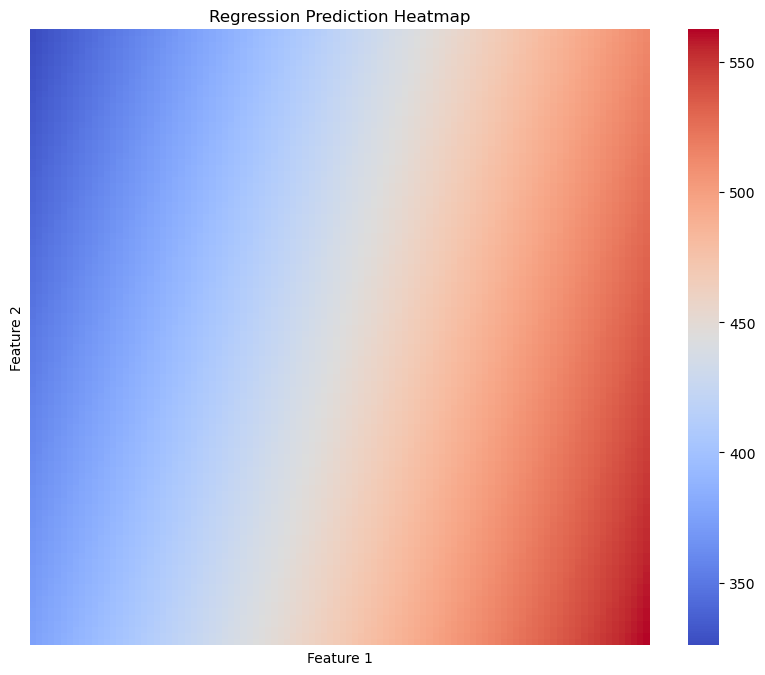

In [71]:
plot_2d_heatmap(X_test_multi, y_pred_multi, model_multi)